# Esame di Metodi Numerici - 6 Luglio 2023

##                             Turno I  ore 9-11.30


## Esercizio 1


Nel file ``Test_I.mat`` sono memorizzate le matrici A1, A2 ed A3 ed i vettori b1,b2,b3. Risolvere i 3 sistemi lineari aventi ciascuno di essi come matrice dei coefficienti A1 e termine noto b1, A2 e termine noto b2, A3 e terimine noto b3  utilizzando il metodo più adatto per ciascuno di essi e  commentare i risultati ottenuti  giustificandoli alla luce della teoria.
Verificare se le matrici sono malcondizionate, dire teoricamente cosa questo implica e verificarlo sperimentalmente almeno per una di esse.


Per la lettura dei dati procedere nel seguente modo:

``from scipy.io import loadmat``

``import numpy as np``

``dati = loadmat('Test_I.mat')``

``A1=dati["A1"] ``

``A1=A1.astype(float)``

`` b1=dati["b1"] ``

`` b1=b1.astype(float)``

``A2=dati["A2"] ``

``A2=A2.astype(float)``

`` b2=dati["b2"] ``

`` b2=b2.astype(float)``

``A3=dati["A3"] ``

``A3=A3.astype(float)``

`` b3=dati["b3"] ``

`` b3=b3.astype(float)``



                                                                    Punti 16

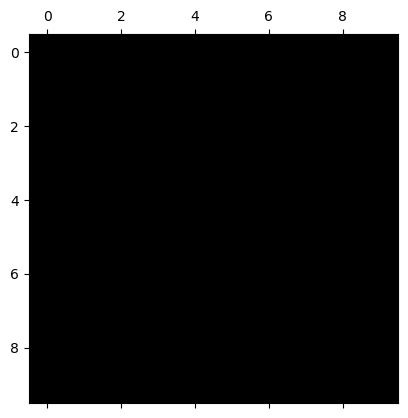

Condizionamento di A1: 120.61487223223202


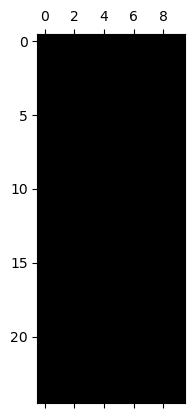

Condizionamento di G1: 99999999.97632413
Condizionamento di R1: 10000.000000001324


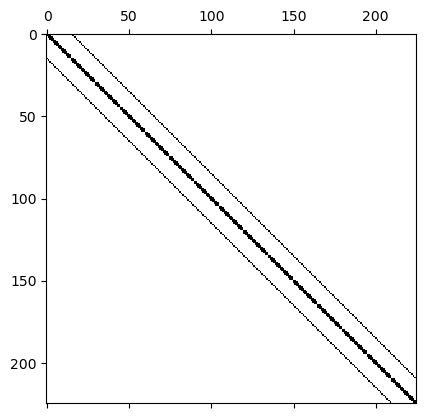

Condizionamento di A3: 103.08686891981688


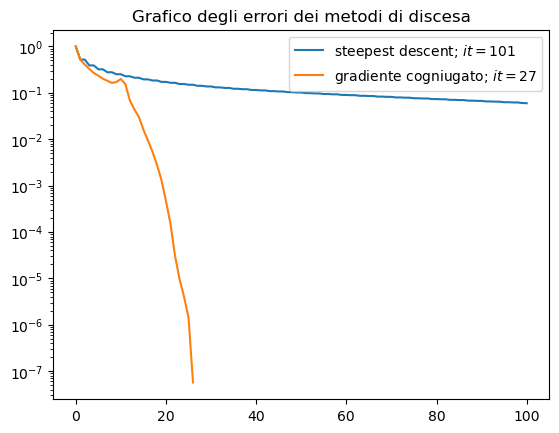

In [41]:
from scipy.io import loadmat
import numpy as np
import numpy.linalg as lin
import scipy.linalg as splin
import matplotlib.pyplot as plt
from RisolviSis import *
from numpy.linalg import matrix_rank as rank

dati = loadmat('Test_I.mat')
A1=dati["A1"]
A1=A1.astype(float)
b1=dati["b1"]
b1=b1.astype(float).ravel()
A2=dati["A2"]
A2=A2.astype(float)
b2=dati["b2"]
b2=b2.astype(float).ravel()
A3=dati["A3"]
A3=A3.astype(float)
b3=dati["b3"]
b3=b3.astype(float).ravel()

plt.spy(A1)
plt.show()
assert(splin.issymmetric(A1))
#Prima matrice è piccola e sparsa usiamo uno dei metodi diretti
#Matrice simmetrica e ma non semidefinita positiva
print(f'Condizionamento di A1: {lin.cond(A1)}')

def qrsolve(A,b):
    Q, R = lin.qr(A)
    return Usolve(R, Q.T @ b)

#Usiamo qrsolve in quanto la matrice e mediamente condizionata
assert(np.allclose(qrsolve(A1, b1), splin.solve(A1, b1)))

#La seconda matrice è un sistema sovradeterminato
plt.spy(A2)
plt.show()
print(f'Condizionamento di G1: {lin.cond(A2.T @ A2)}')
#Matrice mal condizionata usiamo qrLS

def qrLS(A, b):
    Q, R = lin.qr(A)
    R1 = R[:rank(A)]
    print(f'Condizionamento di R1: {lin.cond(R1)}')
    h = Q.T @ b
    return Usolve(R1, h[:rank(A)])

assert(np.allclose(qrLS(A2, b2), np.ones(A2.shape[1])))

#La terza matrice è la matrice di poisson, dunque sappiamo che è simmetrica e semidefinita positiva
plt.spy(A3)
plt.show()

#Usiamo il metodo di discesa, in questo caso è molto utile in quanto è strettamente dominante
from numpy.linalg import norm
from itertools import takewhile

def iterate(func, start):
    while True:
        yield start
        start = func(*start)

def steep(A, b, dir, alfa, toll=1e-6, itmax=100):
    err = lambda num, den: norm(num)/norm(den)
    x0 = np.zeros_like(b)
    stop_criteria = lambda i, args: i < itmax and err(args[1], b) > toll

    def passo(x, r, p):
        a = alfa(A, r, p)
        nr = r + a * (A @ p)
        return x + a*p, nr, dir(nr, r, p)

    r = A @ x0 - b 
    iter = iterate(passo, (x0, r, -r))
    arr = list(dict(takewhile(lambda param: stop_criteria(*param), enumerate(iter))).values()) \
               + [next(iter)]

    x_arr = [x for x, _, p in arr]
    return x_arr[-1], len(x_arr), [err(r, b) for _, r, p in arr]

def steepest(A, b):
    alfa = lambda A, r, p: -r.T @ p / (A.T @ p @ p)
    dir = lambda nr, r, p: -r
    return steep(A, b, dir, alfa)

def conj(A, b):
    alfa = lambda A, r, p: r.T @ r / (A.T @ p @ p)
    def dir(nr, r, p): 
        gamma = (nr.T @ nr) / (r.T @ r)
        return -nr + (gamma * p)

    return steep(A, b, dir, alfa)

def plot_err(A, b, method, name):
    _, it, err = method(A, b)
    plt.semilogy(range(it), err, label=name + '; $it='+f'{it}'+'$')
    plt.legend()

print(f'Condizionamento di A3: {lin.cond(A3)}')
#Matrice mediamente condizionata
plot_err(A3, b3, steepest, 'steepest descent')
plot_err(A3, b3, conj, 'gradiente cogniugato')
plt.title('Grafico degli errori dei metodi di discesa')
plt.show()



# Esercizio 2

Data l'equazione di 2° grado $$\frac{1}{2} x^2+2bx-c=0$$

con $b=10^8, c=2^{-i},i=-5,\cdots, 9$

- a) Scrivere le due formule algebriche per ricavare i valori delle 2 soluzioni

                                                                                    1 punto
- b) Studiare l'indice di condizionamento delle 2 formule algebriche, facendo uso del risultato teorico visto a lezione riguardo l'indice di condizionamento della valutazione di una funzione. (Spiegare il significato di problema mal condizionato) e dire quale delle due formule è malcondizionata. Per quali valori di $c$ il problema risulterebbe ben condizionato?

                                                                                    5 punti

- c) Nel caso in cui una delle due formule risulti mal condizionata, proporre una soluzione algebricamente equivalente che non sia malcondizionata.

                                                                                    3 punti

Soluzioni x1 (Metodo del delta)→ [7.45058060e-08 4.47034836e-08 1.49011612e-08 1.49011612e-08
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]

Indice di condizionamento → [0.4822201  0.5277644  0.42695316 0.5984123  0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.        ]

Soluzioni x1 (Metodo del prodtto) → [3.200000e-07 1.600000e-07 8.000000e-08 4.000000e-08 2.000000e-08
 1.000000e-08 5.000000e-09 2.500000e-09 1.250000e-09 6.250000e-10
 3.125000e-10 1.562500e-10 7.812500e-11 3.906250e-11 1.953125e-11]

Indice di condizionamento → [0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8]


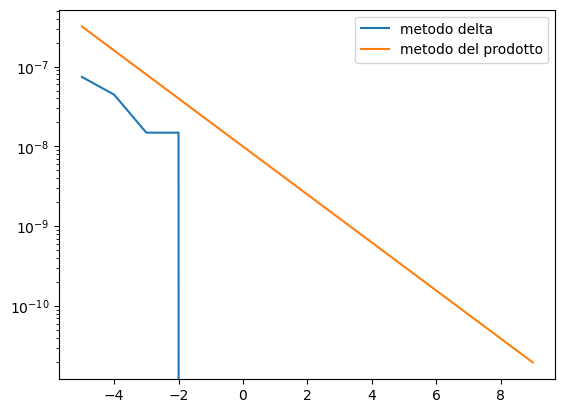

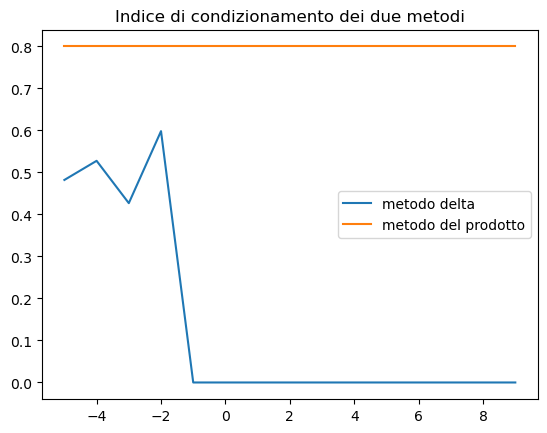

In [105]:
import sympy as sym
import sympy.utilities.lambdify as lambdify

equa2 = lambda x, a, b, c: 1/2*a*x**2 + 2*b*x - c
derivata = lambda x, a, b, c: a*x + 2*b

def delta_sol(a, b, c):
    delta = np.sqrt(b**2 - 4*(a*c))
    return (-b + delta) / 2, (-b - delta) / 2

def prod_sol(a, b, c):
    x2 = delta_sol(a, b, c)[1]
    return c / a / x2, x2
    
i = np.arange(-5, 10, 1)
a = 1/2
b = 2*10**8
c = -2. **(-i)

args = a, b, c
K = lambda x, func, diff: (diff(x, *args) * x) / (func(x, *args))

arr_x1 = delta_sol(*args)[0]
print(f'Soluzioni x1 (Metodo del delta)→ {arr_x1}\n')
plt.semilogy(i, arr_x1,  label='metodo delta')
i_k1 = K(arr_x1, equa2, derivata)
print(f'Indice di condizionamento → {i_k1}\n')

arr_x1 = prod_sol(*args)[0]
print(f'Soluzioni x1 (Metodo del prodtto) → {arr_x1}\n')
plt.semilogy(i, arr_x1, label='metodo del prodotto')
i_k2 = K(arr_x1, equa2, derivata)
print(f'Indice di condizionamento → {i_k2}')
plt.legend()
plt.show()

#Mostro il confronto degli indici di condizionamento, il secondo è maggiormente stabile
#mentre il primo ha degli intoppi appena la c comincia ad essere prossima allo zero, quindi i negativi
plt.plot(i, i_k1,  label='metodo delta')
plt.plot(i, i_k2,  label='metodo del prodotto')
plt.title('Indice di condizionamento dei due metodi')
plt.legend()
plt.show()


                                                                        Totale 9 punti

## Domanda intelligenza artificiale

- Limiti delle reti MLP (multilayer Perceptron) ed introduzione delle Reti neurali Convoluzionali. 
- Architettura di una rete neurale convoluzionale: strati convoluzionali, attivazione non lineare e pooling + parte fully connected.
- Loss function per il task della regressione.  Training di una rete. 
- Cenni sull'algoritmo di backpropagation per il calcolo delle derivate parziale della funzione costo rispetto ai pesi ditutti i layer .
- Tecniche di Ottimizzazione: metodo di discesa del gradient batch, metodo del gradiente stocastico (SGD) ,metodo del gradiente stocastico minibatch.
                                                                                [7  punti]
